In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from pyvis.network import Network
from scipy import stats
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load network
G = nx.read_edgelist('../inf-euroroad/inf-euroroad.edges', comments='%', nodetype=int)

In [4]:
# Basic info
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Connected: {nx.is_connected(G)}")

Nodes: 1174
Edges: 1417
Connected: False


In [5]:
# Compute node degrees
degrees = dict(G.degree())

# Create the Pyvis network
net = Network(notebook=True, height="800px", width="100%", bgcolor="white", font_color="black")

# Add nodes with colors and size proportional to degree
for node in G.nodes():
    degree = degrees[node]
    net.add_node(
        node,
        title=f"Node {node}, degree {degree}",  # tooltip info when hovering
        value=degree*5,                          # Pyvis uses 'value' for node size
        color=f"rgba(255, {255 - degree*10}, 0, 0.8)"  # simple color based on degree
    )

# Add edges
for edge in G.edges():
    net.add_edge(edge[0], edge[1])

# Display in notebook or save as HTML
net.show("network.html")

network.html


In [7]:
# Create configuration model (preserving degree sequence)
degree_sequence = [d for n, d in G.degree()]
G_random = nx.configuration_model(degree_sequence, seed=42)

# Remove self-loops and parallel edges from randomized network
G_random = nx.Graph(G_random)
G_random.remove_edges_from(nx.selfloop_edges(G_random))

print(f"Original network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Randomized network: {G_random.number_of_nodes()} nodes, {G_random.number_of_edges()} edges")

Original network: 1174 nodes, 1417 edges
Randomized network: 1174 nodes, 1413 edges


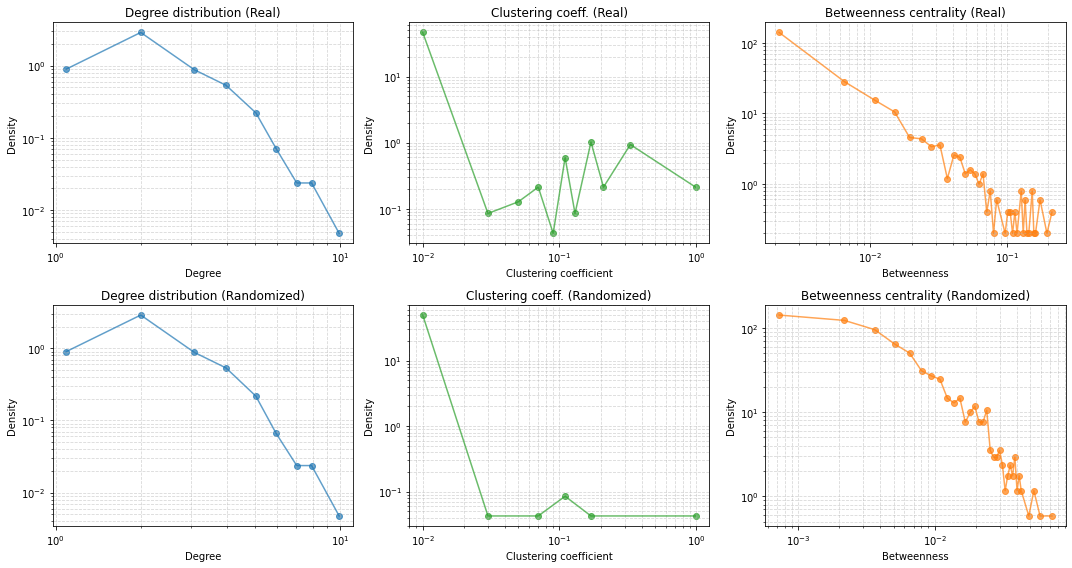

In [8]:
# --- Metrics ---
# Degree
deg_real = [d for n, d in G.degree()]
deg_rand = [d for n, d in G_random.degree()]

# Clustering
clust_real = list(nx.clustering(G).values())
clust_rand = list(nx.clustering(G_random).values())

# Betweenness
betw_real = list(nx.betweenness_centrality(G).values())
betw_rand = list(nx.betweenness_centrality(G_random).values())

# --- Function to compute distributions ---
def distribution(data, bins=50, log=True):
    counts, bin_edges = np.histogram(data, bins=bins, density=True)
    x = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    y = counts
    if log:
        mask = (x > 0) & (y > 0)
        return x[mask], y[mask]
    return x, y

# --- Plotting ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Degree
for ax, data, label, color in [
    (axes[0,0], deg_real, "Real", "tab:blue"),
    (axes[1,0], deg_rand, "Randomized", "tab:blue")]:
    x, y = distribution(data, bins=50)
    ax.scatter(x, y, alpha=0.7, color=color, label=label)
    ax.plot(x, y, color=color, alpha=0.7)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"Degree distribution ({label})")
    ax.set_xlabel("Degree")
    ax.set_ylabel("Density")
    ax.grid(True, which="both", ls="--", alpha=0.5)

# Clustering
for ax, data, label, color in [
    (axes[0,1], clust_real, "Real", "tab:green"),
    (axes[1,1], clust_rand, "Randomized", "tab:green")]:
    x, y = distribution(data, bins=50)
    ax.scatter(x, y, alpha=0.7, color=color, label=label)
    ax.plot(x, y, color=color, alpha=0.7)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"Clustering coeff. ({label})")
    ax.set_xlabel("Clustering coefficient")
    ax.set_ylabel("Density")
    ax.grid(True, which="both", ls="--", alpha=0.5)

# Betweenness
for ax, data, label, color in [
    (axes[0,2], betw_real, "Real", "tab:orange"),
    (axes[1,2], betw_rand, "Randomized", "tab:orange")]:
    x, y = distribution(data, bins=50)
    ax.scatter(x, y, alpha=0.7, color=color, label=label)
    ax.plot(x, y, color=color, alpha=0.7)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"Betweenness centrality ({label})")
    ax.set_xlabel("Betweenness")
    ax.set_ylabel("Density")
    ax.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.savefig("Real_vs_Randomized.pdf", format="pdf", dpi=300)
plt.show()

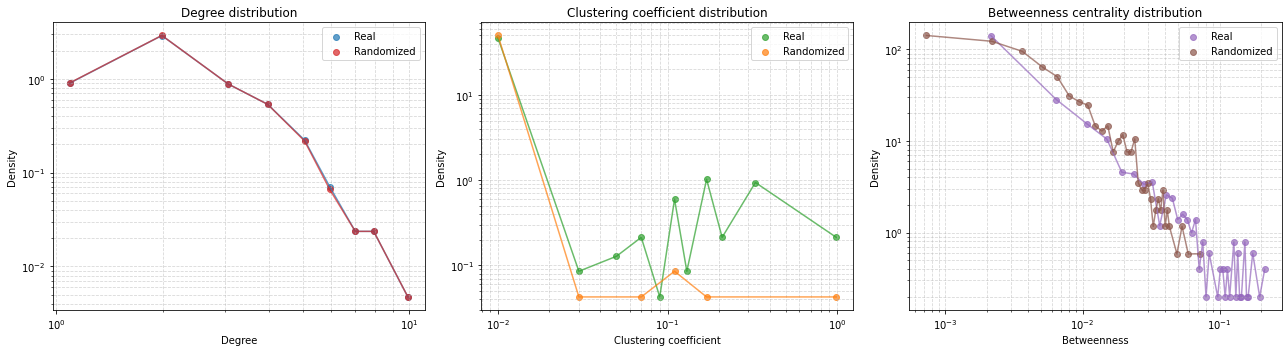

In [9]:
# --- Plotting combined ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Degree
x_real, y_real = distribution(deg_real, bins=50)
x_rand, y_rand = distribution(deg_rand, bins=50)
axes[0].scatter(x_real, y_real, alpha=0.7, color="tab:blue", label="Real")
axes[0].plot(x_real, y_real, color="tab:blue", alpha=0.7)
axes[0].scatter(x_rand, y_rand, alpha=0.7, color="tab:red", label="Randomized")
axes[0].plot(x_rand, y_rand, color="tab:red", alpha=0.7)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Degree distribution")
axes[0].set_xlabel("Degree")
axes[0].set_ylabel("Density")
axes[0].grid(True, which="both", ls="--", alpha=0.5)
axes[0].legend()

# Clustering
x_real, y_real = distribution(clust_real, bins=50)
x_rand, y_rand = distribution(clust_rand, bins=50)
axes[1].scatter(x_real, y_real, alpha=0.7, color="tab:green", label="Real")
axes[1].plot(x_real, y_real, color="tab:green", alpha=0.7)
axes[1].scatter(x_rand, y_rand, alpha=0.7, color="tab:orange", label="Randomized")
axes[1].plot(x_rand, y_rand, color="tab:orange", alpha=0.7)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Clustering coefficient distribution")
axes[1].set_xlabel("Clustering coefficient")
axes[1].set_ylabel("Density")
axes[1].grid(True, which="both", ls="--", alpha=0.5)
axes[1].legend()

# Betweenness
x_real, y_real = distribution(betw_real, bins=50)
x_rand, y_rand = distribution(betw_rand, bins=50)
axes[2].scatter(x_real, y_real, alpha=0.7, color="tab:purple", label="Real")
axes[2].plot(x_real, y_real, color="tab:purple", alpha=0.7)
axes[2].scatter(x_rand, y_rand, alpha=0.7, color="tab:brown", label="Randomized")
axes[2].plot(x_rand, y_rand, color="tab:brown", alpha=0.7)
axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].set_title("Betweenness centrality distribution")
axes[2].set_xlabel("Betweenness")
axes[2].set_ylabel("Density")
axes[2].grid(True, which="both", ls="--", alpha=0.5)
axes[2].legend()

plt.tight_layout()
plt.savefig("Real_vs_Randomized_same_plot.pdf", format="pdf", dpi=300)
plt.show()